# MIOFlow

## Workflow
1. Load pre-processed SERGIO simulation AnnData
2. Train a **GAGA autoencoder** (`gaga.py`) — learns a geometry-preserving latent embedding from PCA, regularised by PHATE distances
3. Pass the trained GAGA model to `MIOFlow` and call `fit()` — trains a Neural ODE in GAGA latent space using optimal transport
4. Inspect losses and trajectories
5. `decode_to_gene_space()` — maps trajectories back through the GAGA decoder and PCA components to recover gene-level predictions

In [1]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from mioflow import MIOFlow, fit_gaga


## 1. Load Data

In [2]:
adata = sc.read_h5ad('data/scRNAseq/preprocessed_eb_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 16826 × 17845
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'pca', 'timepoint_colors'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'

In [3]:
time_column = 'time_bin'  # Set the time_column for your dataset

Set the time_column for your dataset

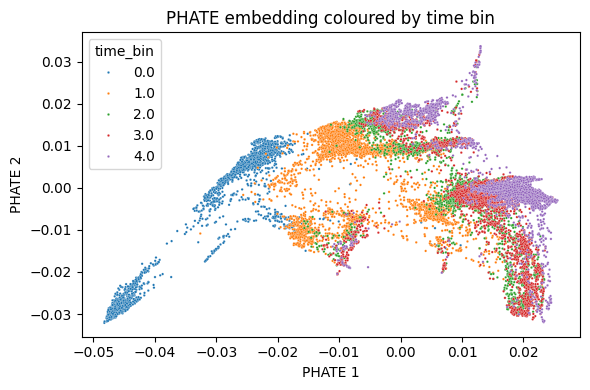

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    x=adata.obsm['X_phate'][:, 0],
    y=adata.obsm['X_phate'][:, 1],
    hue=adata.obs[time_column],
    palette='tab10',
    s=3,
    ax=ax,
)
ax.set_xlabel('PHATE 1')
ax.set_ylabel('PHATE 2')
ax.set_title('PHATE embedding coloured by time bin')
plt.tight_layout()
plt.show()

## 2. Train GAGA Autoencoder

GAGA (`gaga.py`) trains a two-phase autoencoder on PCA embeddings, regularised by PHATE distances:

- **Phase 1** — encoder learns a geometry-preserving latent space (distance preservation loss, decoder frozen)
- **Phase 2** — decoder learns to reconstruct PCA coordinates (reconstruction loss, encoder frozen)

The resulting latent space is where the MIOFlow ODE will be trained.

In [5]:
gaga_model = fit_gaga(
    X_pca      = adata.obsm['X_pca'],
    X_phate    = adata.obsm['X_phate'],
    latent_dim = 2,
    hidden_dims= [128, 64],
    batch_size = 1024,
    encoder_epochs=300,
    decoder_epochs=300,
    learning_rate=1e-3,
    dist_weight_phase1=1.0,
    recon_weight_phase2=1.0,
)

GAGA architecture: 50 → 2
Phase 1: Training encoder (decoder frozen) for distance preservation
Training GAGA on device: cpu
Encoder frozen: False, Decoder frozen: True
Reconstruction weight: 0.0, Distance weight: 1.0


Epochs: 100%|██████████| 300/300 [01:08<00:00,  4.41it/s, train_loss=0.0064, recon=1.0154, dist=0.0064]



Phase 2: Training decoder (encoder frozen) for reconstruction
Training GAGA on device: cpu
Encoder frozen: True, Decoder frozen: False
Reconstruction weight: 1.0, Distance weight: 0.0


Epochs: 100%|██████████| 300/300 [00:42<00:00,  7.03it/s, train_loss=0.7541, recon=0.7541, dist=0.0060]


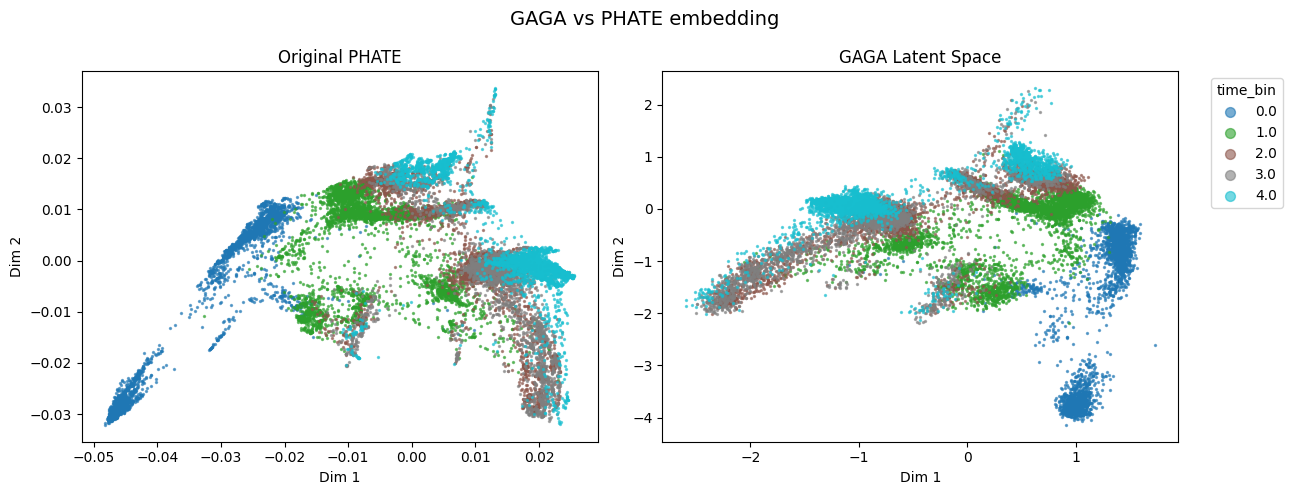

In [6]:
# quick sanity-check: compare GAGA latent space with original PHATE
X_pca_scaled = gaga_model.input_scaler.transform(adata.obsm['X_pca'].astype('float32'))
gaga_model.eval()
with torch.no_grad():
    gaga_embeddings = gaga_model.encode(torch.tensor(X_pca_scaled)).numpy()

adata.obsm['X_gaga'] = gaga_embeddings

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = adata.obs[time_column].astype('category').cat
codes = categories.codes.values
cat_names = categories.categories
colors = plt.cm.tab10(np.linspace(0, 1, len(cat_names)))

for ax, key, title in zip(
    axes,
    ['X_phate', 'X_gaga'],
    ['Original PHATE', 'GAGA Latent Space'],
):
    for i, name in enumerate(cat_names):
        mask = codes == i
        ax.scatter(
            adata.obsm[key][mask, 0], adata.obsm[key][mask, 1],
            color=colors[i], s=2, alpha=0.6, label=name,
        )
    ax.set_title(title)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

axes[-1].legend(title=time_column, bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5)
plt.suptitle('GAGA vs PHATE embedding', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Configure and Initialise MIOFlow

Pass the trained `gaga_model` to `MIOFlow`. The input scaler is read automatically from `gaga_model.input_scaler`.
`MIOFlow` will use the encoder to embed cells into latent space for ODE training, and the decoder in `decode_to_gene_space()`.

In [7]:
mioflow_model = MIOFlow(
    adata,
    gaga_model=gaga_model,
    obs_time_key=time_column,
    debug_level='info',
    hidden_dim=64,
    use_cuda=torch.cuda.is_available(),
    momentum_beta=0.0,
    scheduler_type='cosine',
    learning_rate=1e-3,
    scheduler_t_max=300,
    scheduler_min_lr=1e-5,
    # Training phases
    n_epochs=300,
    # Loss
    use_density_loss=True,
    lambda_ot=1.0,
    lambda_density=0.001,
    lambda_energy=0.1,
    energy_time_steps=20,
    # Data / output
    sample_size=100,
    n_trajectories=100,
    n_bins=100,
    exp_dir='.',
)


2026-03-30 15:22:17,359 - MIOFlow - INFO - MIOFlow initialised | 16826 cells, 17845 genes | device=cpu


## 4. Fit — `~5 minutes`

`fit()` runs three phases under the hood:
1. **Training** (`n_local_epochs`) — trains each consecutive time-point pair independently

The ODE operates entirely in the GAGA latent space.

In [8]:
mioflow_model.fit()
print(mioflow_model)

2026-03-30 15:22:17,364 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=64
2026-03-30 15:22:17,365 - MIOFlow - INFO - Global training: 300 epochs
Training (global):  20%|█▉        | 59/300 [00:08<00:34,  6.98it/s]


KeyboardInterrupt: 

## 4. Training Losses

After fitting:
- `mf.losses` — list of dicts `{'Total', 'OT', 'Density', 'Energy'}` per epoch (local phase)

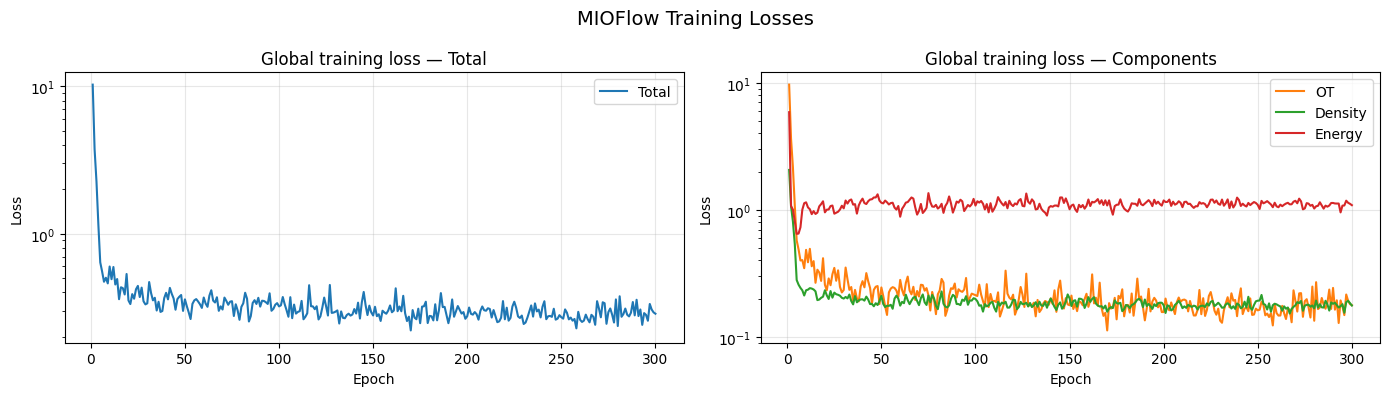

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Losses ───────────────────────────────────────────────────────────
epochs = mioflow_model.losses['epoch']

# Left: total loss
ax = axes[0]
ax.plot(epochs, mioflow_model.losses['total_loss'], label='Total', color='tab:blue')
ax.set_title('Global training loss — Total')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: individual loss components
ax = axes[1]
ax.plot(epochs, mioflow_model.losses['ot_loss'],      label='OT',      color='tab:orange')
ax.plot(epochs, mioflow_model.losses['density_loss'], label='Density', color='tab:green')
ax.plot(epochs, mioflow_model.losses['energy_loss'],  label='Energy',  color='tab:red')
ax.set_title('Global training loss — Components')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('MIOFlow Training Losses', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Trajectories in GAGA Latent Space

`mf.trajectories` has shape **`(n_bins, n_trajectories, latent_dim)`**.

To iterate over individual trajectories use `mf.trajectories[:, i, :]`.

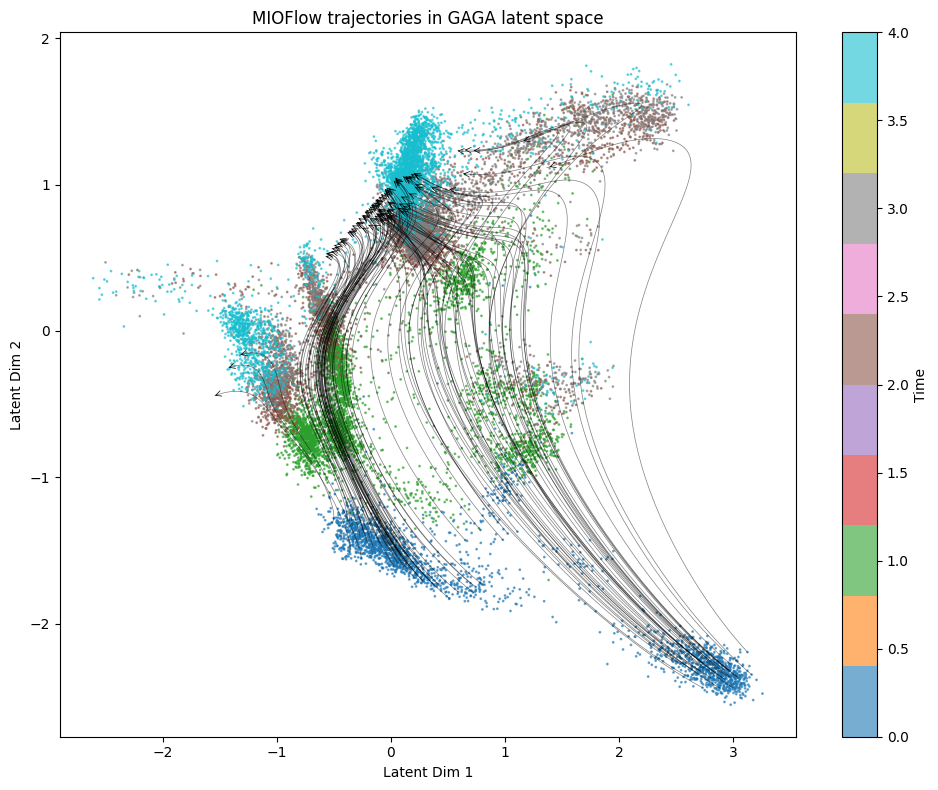

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sc_plot = ax.scatter(
    mioflow_model.embedding[:, 0], mioflow_model.embedding[:, 1],
    c=mioflow_model._time_labels, cmap='tab10', s=1, alpha=0.6,
)
plt.colorbar(sc_plot, ax=ax, label='Time')

for traj in mioflow_model.trajectories.transpose(1, 0, 2):  # (n_traj, n_bins, latent_dim)
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.5, linewidth=0.5, color='black')
    ax.annotate(
        '', xy=(traj[-1, 0], traj[-1, 1]), xytext=(traj[-2, 0], traj[-2, 1]),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.5, mutation_scale=10),
    )

ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_title('MIOFlow trajectories in GAGA latent space')
plt.tight_layout()
plt.show()


## 6. Decode to Gene Space

`decode_to_gene_space()` maps trajectories through the chain:

**GAGA latent → GAGA decoder → PCA space (inverse scaler) → gene space**

Returns shape **`(n_bins, n_trajectories, n_genes)`**.

In [ ]:
trajectories_gene_space = mioflow_model.decode_to_gene_space()
print('Gene-space trajectory shape (n_bins, n_trajectories, n_genes):',
      trajectories_gene_space.shape)

Gene-space trajectory shape (n_bins, n_trajectories, n_genes): (100, 100, 17845)


## 7. Gene Trends — Top Highly-Variable Genes

We plot the mean expression (± std) over all trajectories at each time bin.

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=25)
example_genes     = adata.var_names[adata.var['highly_variable']]
example_gene_mask = adata.var_names.isin(example_genes)
print(example_genes)

Index(['NPPB', 'S100A14', 'TNNT2', 'LEFTY2', 'ACTA1', 'TAGLN3', 'TRH', 'AHSG',
       'CXCL10', 'SPP1', 'FGB', 'CCNO', 'NEUROG1', 'NEFM', 'NEFL', 'PENK',
       'LCN15', 'HBE1', 'LYZ', 'SERPINA1', 'MT2A', 'MYL4', 'PRTN3', 'GALP',
       'TFF3'],
      dtype='object')


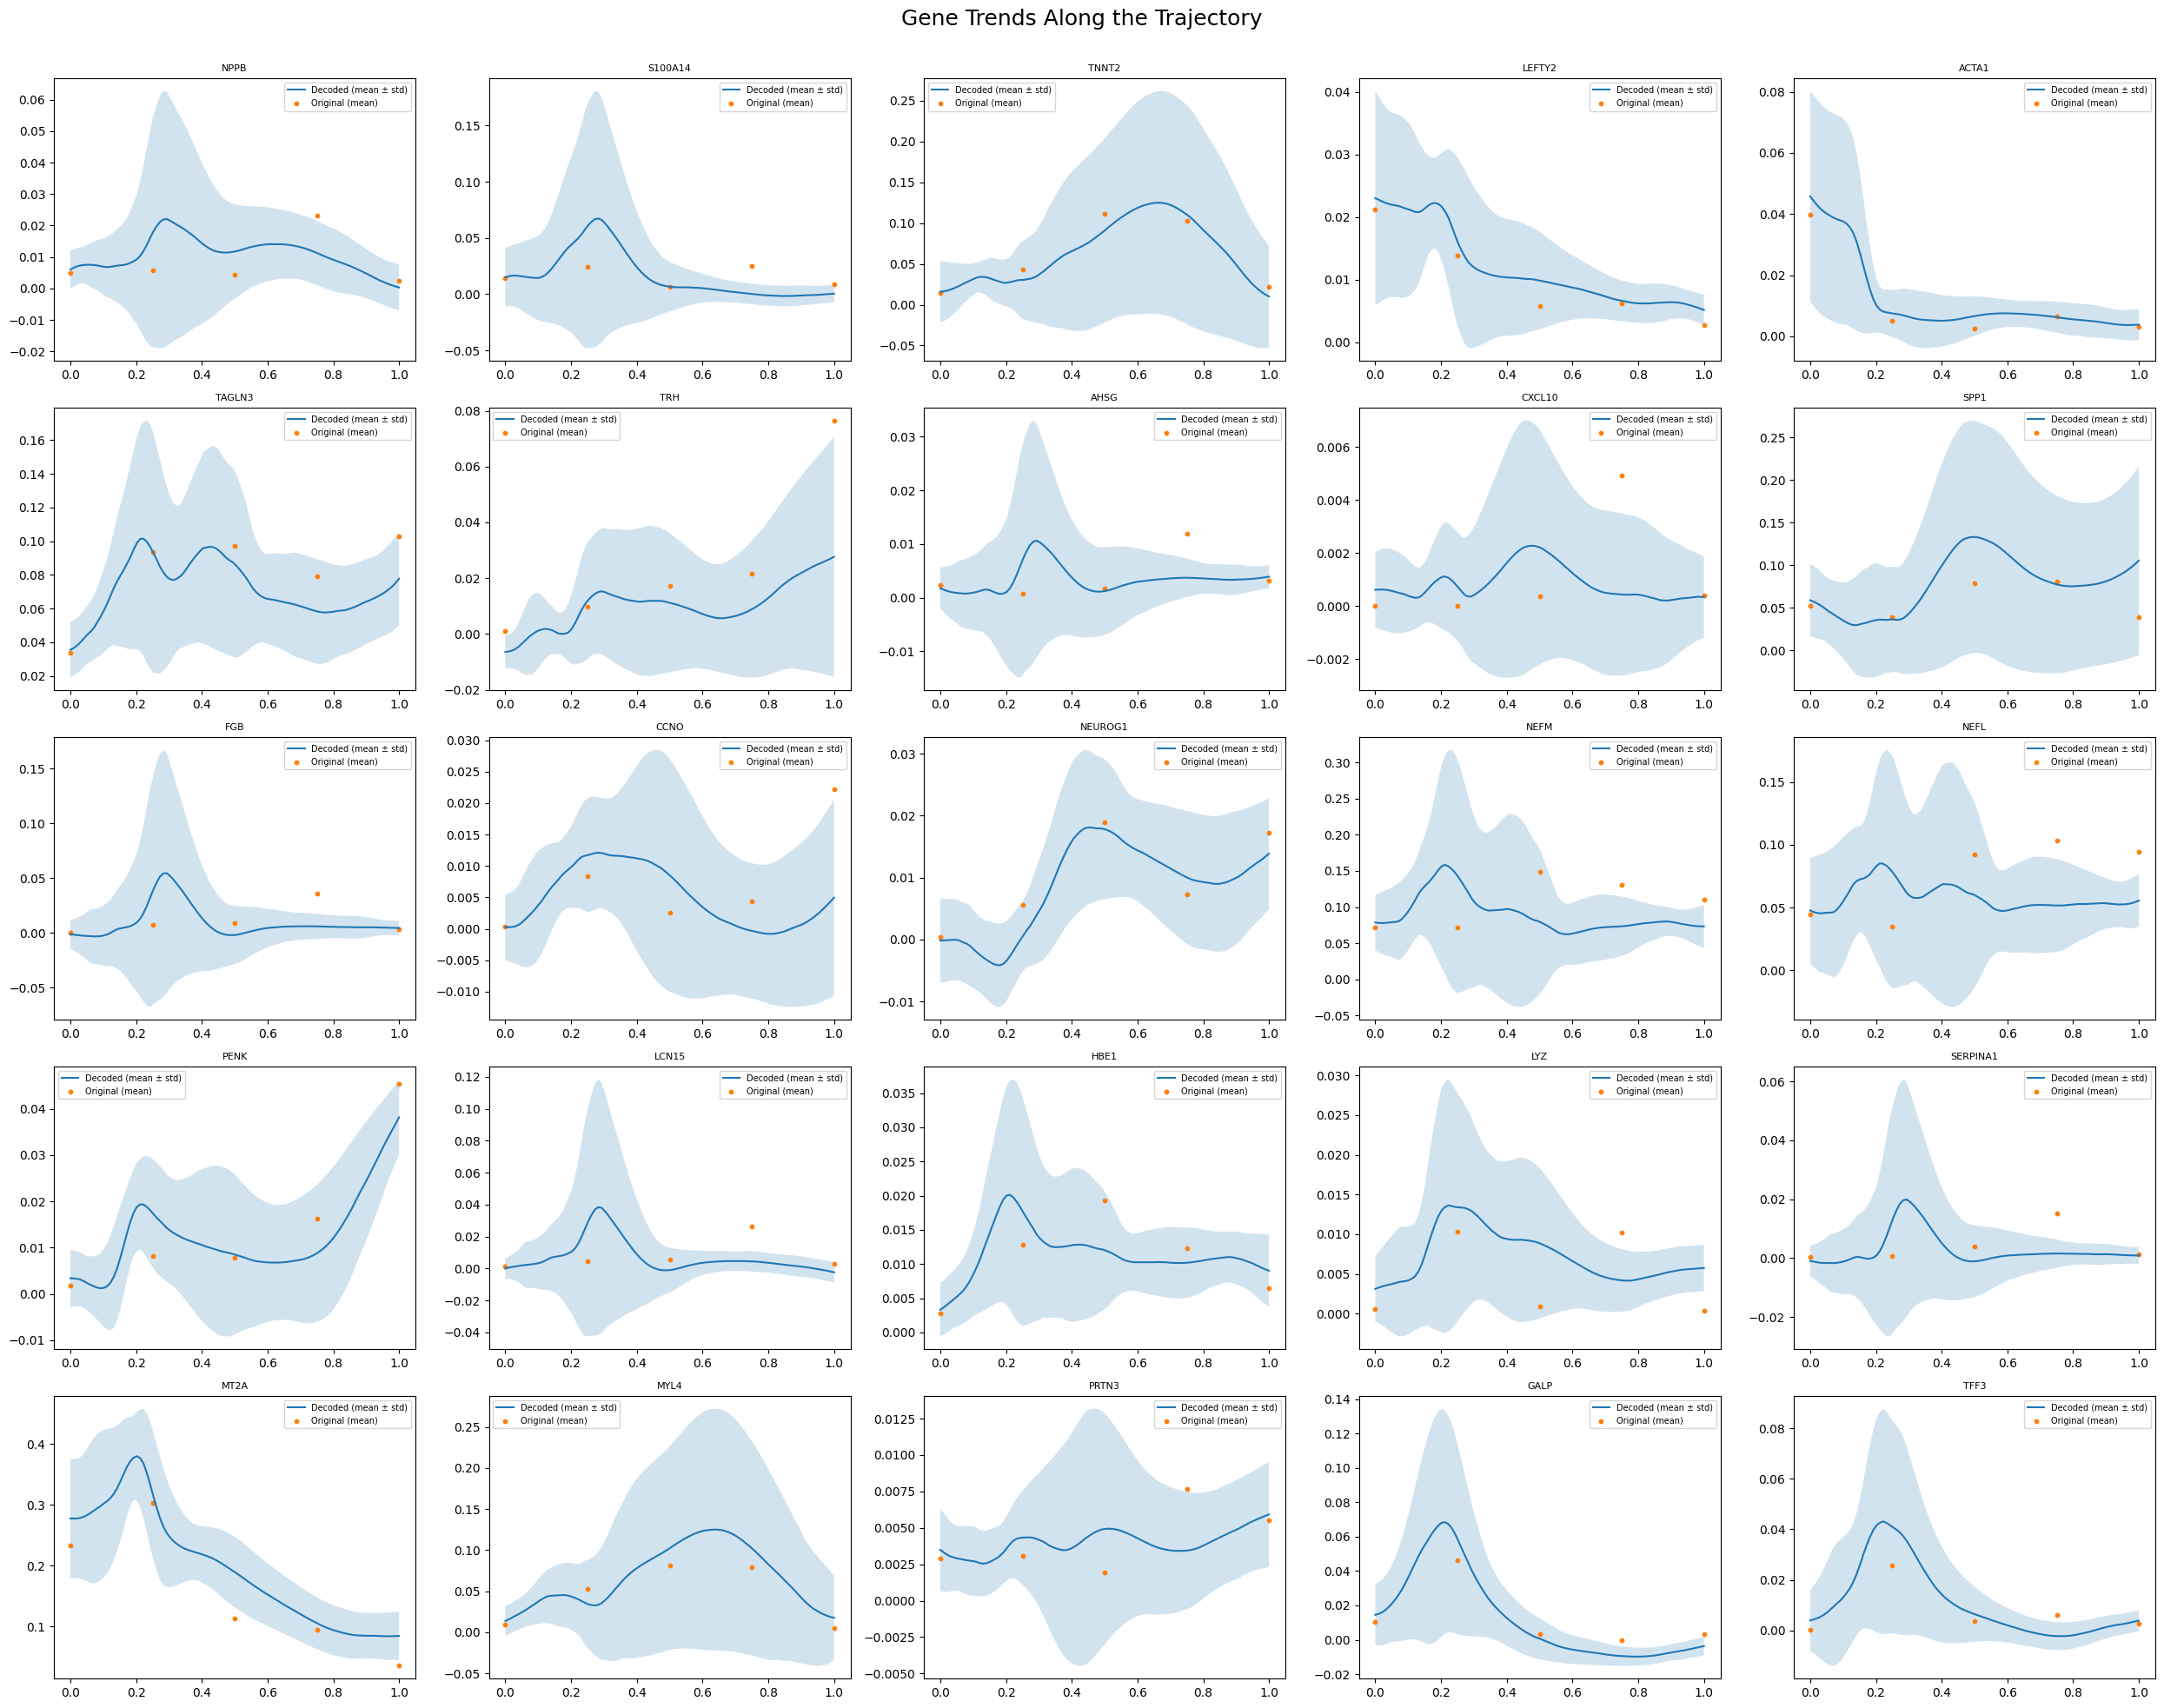

In [ ]:
# decoded shape: (n_bins, n_trajectories, n_selected_genes)
decoded_example_gene = trajectories_gene_space[:, :, example_gene_mask]

# Mean / std over trajectories (axis=1) → (n_bins, n_selected_genes)
decoded_mean = decoded_example_gene.mean(axis=1)
decoded_std  = decoded_example_gene.std(axis=1)

# Normalised time axis
x_time = np.linspace(0, 1, decoded_mean.shape[0])

# Reconstruct integer time labels the same way MIOFlow does internally
t = mioflow_model._time_labels.astype(float)
obs_time_norm = (t - t.min()) / (t.max() - t.min())

# Original data aggregated by time
adata_sel = adata[:, example_gene_mask]
data_df   = pd.DataFrame(adata_sel.X.toarray(), columns=example_genes)
data_df['t'] = obs_time_norm
data_mean = data_df.groupby('t').mean()

# Grid plot
n_genes = decoded_mean.shape[1]
n_cols  = int(np.ceil(np.sqrt(n_genes)))
n_rows  = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, gene in enumerate(example_genes):
    ax = axes[i]
    ax.plot(x_time, decoded_mean[:, i], label='Decoded (mean ± std)')
    ax.fill_between(x_time,
                    decoded_mean[:, i] - decoded_std[:, i],
                    decoded_mean[:, i] + decoded_std[:, i],
                    alpha=0.2)
    ax.scatter(data_mean.index, data_mean[gene], s=10, label='Original (mean)')
    ax.set_title(gene, fontsize=8)
    ax.legend(fontsize=7)

for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Gene Trends Along the Trajectory', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


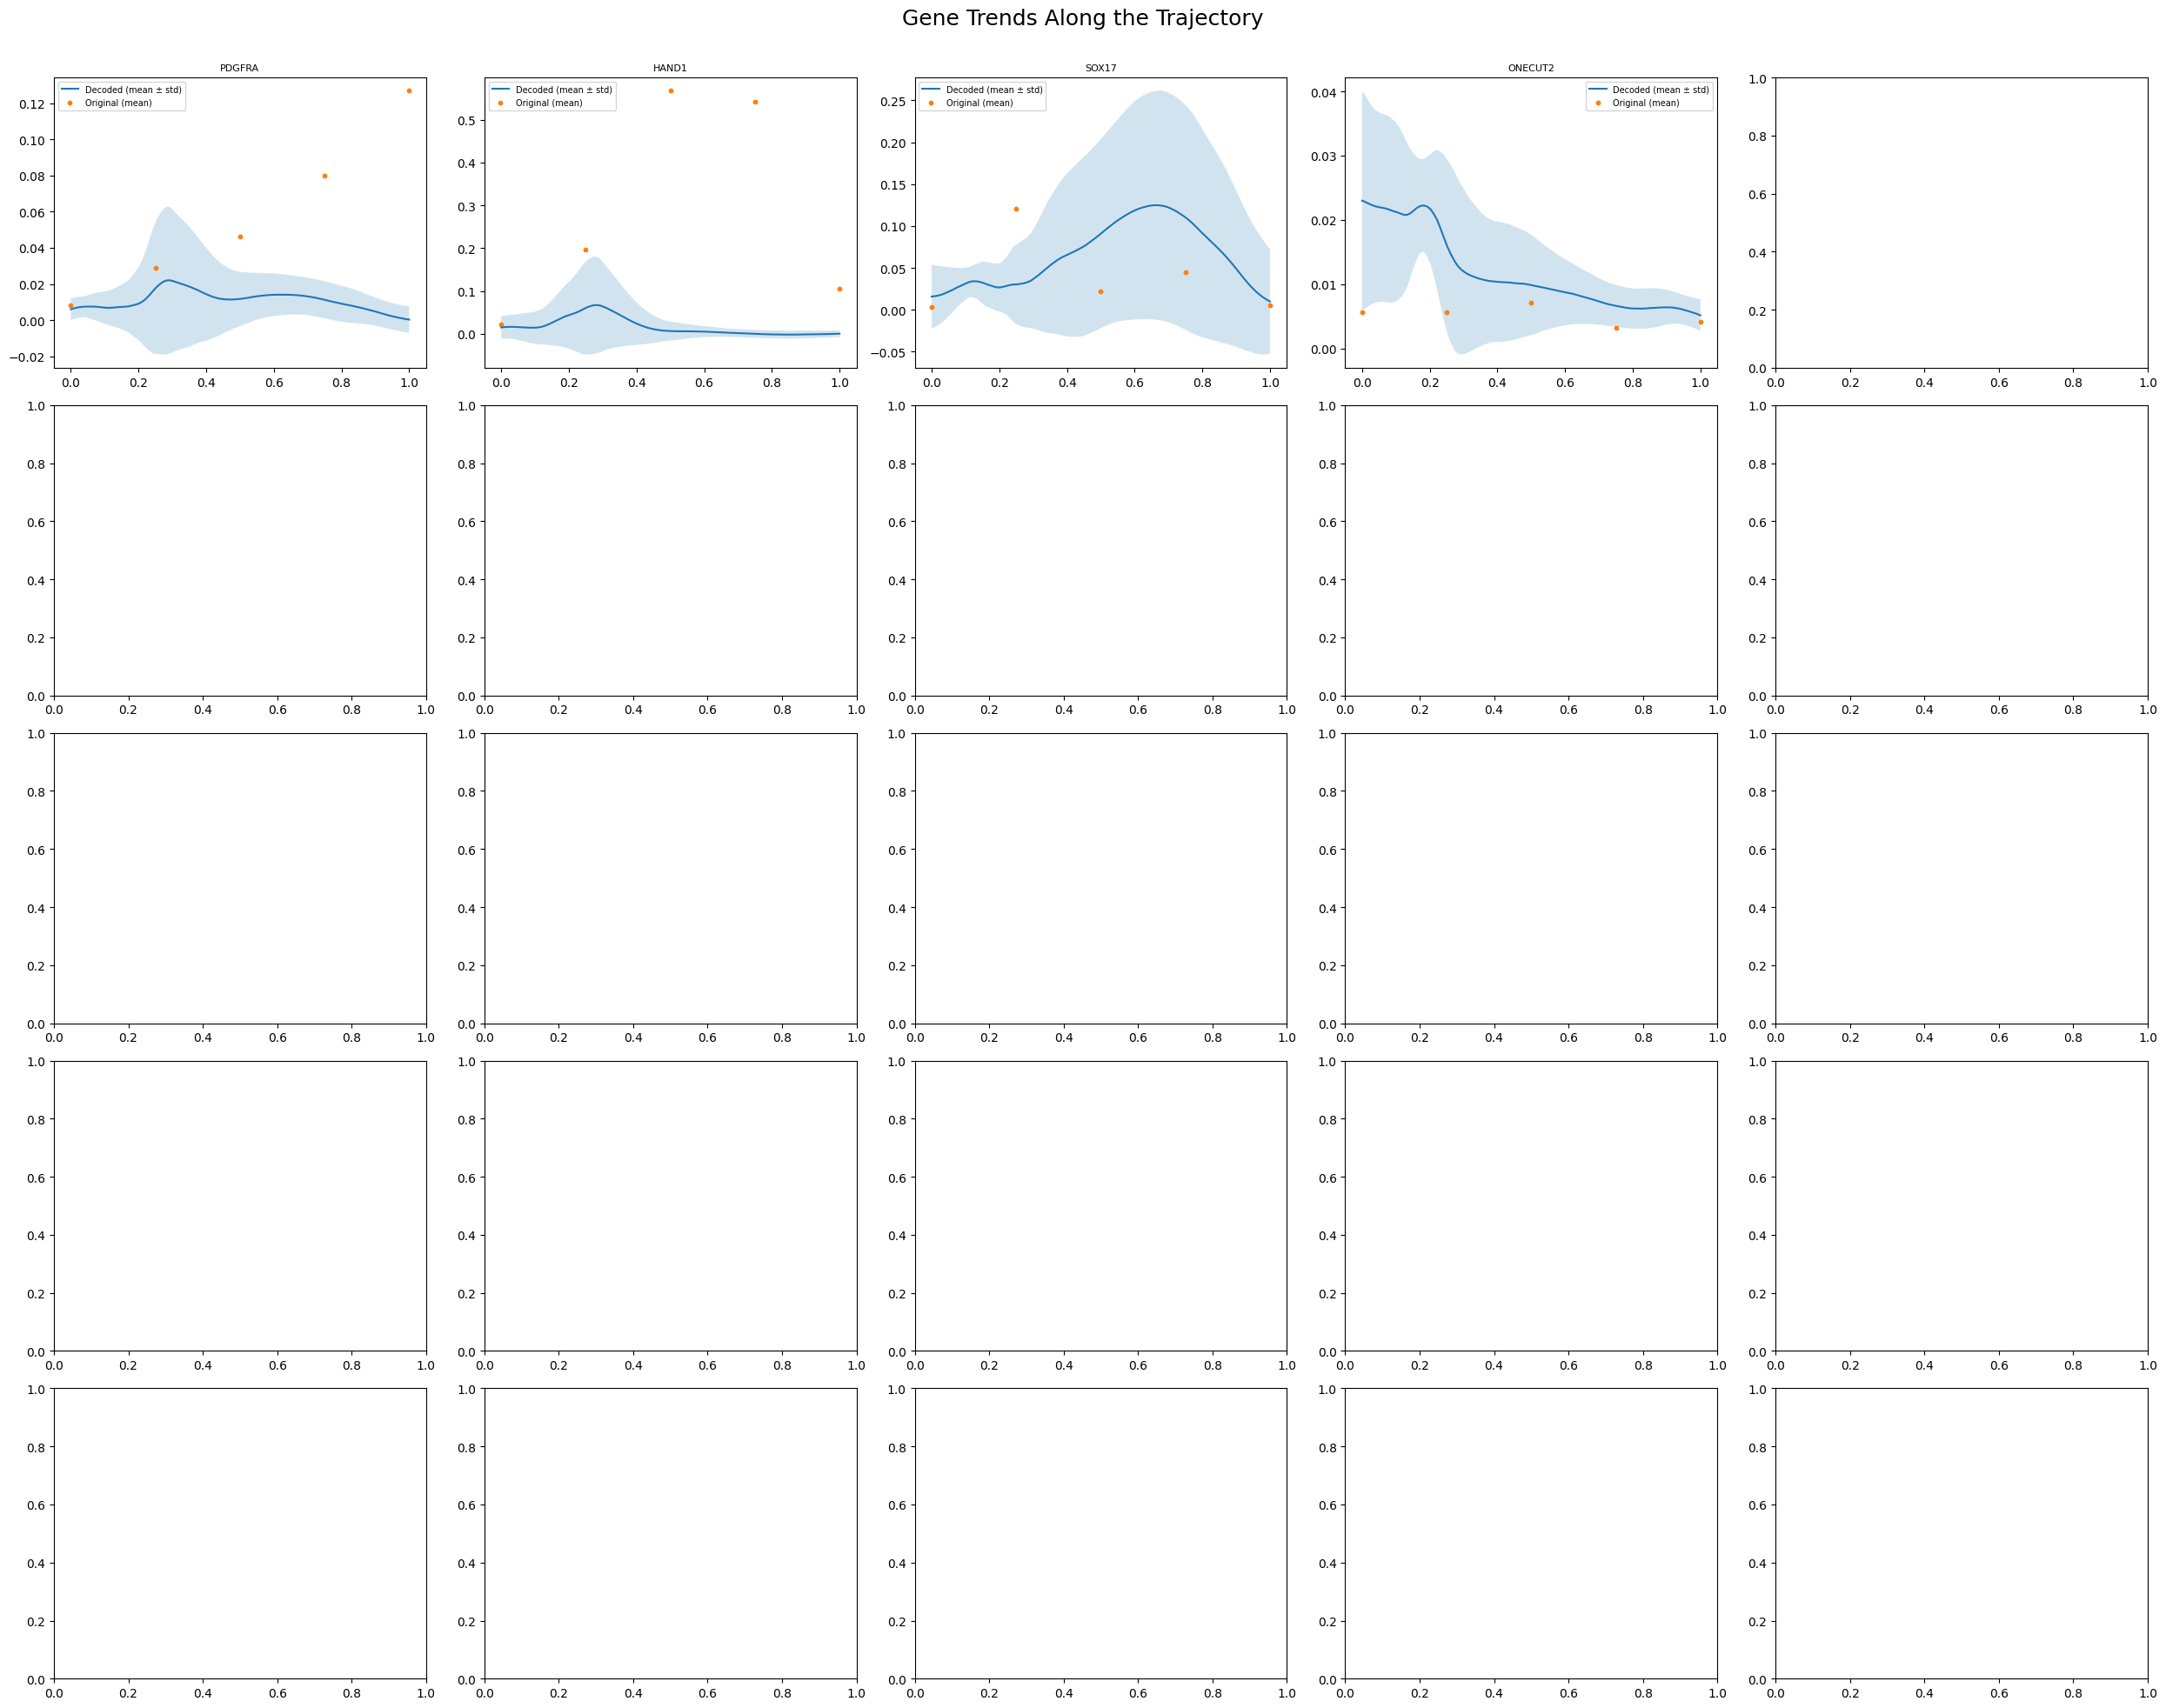

In [ ]:
curated = ['PDGFRA', 'HAND1', 'SOX17', 'ONECUT2']
missing = [g for g in curated if g not in adata.var_names]
if missing:
    print(f"Warning: genes not found in adata: {missing}")

example_gene_mask = adata.var_names.isin(curated)
example_genes = adata.var_names[example_gene_mask]

# Normalised time axis
x_time = np.linspace(0, 1, decoded_mean.shape[0])

# Reconstruct integer time labels the same way MIOFlow does internally
t = mioflow_model._time_labels.astype(float)
obs_time_norm = (t - t.min()) / (t.max() - t.min())

# Original data aggregated by time
adata_sel = adata[:, example_gene_mask]
data_df   = pd.DataFrame(adata_sel.X.toarray(), columns=example_genes)
data_df['t'] = obs_time_norm
data_mean = data_df.groupby('t').mean()

# Grid plot
n_genes = decoded_mean.shape[1]
n_cols  = int(np.ceil(np.sqrt(n_genes)))
n_rows  = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, gene in enumerate(example_genes):
    ax = axes[i]
    ax.plot(x_time, decoded_mean[:, i], label='Decoded (mean ± std)')
    ax.fill_between(x_time,
                    decoded_mean[:, i] - decoded_std[:, i],
                    decoded_mean[:, i] + decoded_std[:, i],
                    alpha=0.2)
    ax.scatter(data_mean.index, data_mean[gene], s=10, label='Original (mean)')
    ax.set_title(gene, fontsize=8)
    ax.legend(fontsize=7)

for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Gene Trends Along the Trajectory', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()
